In [19]:
import nltk
import pandas as pd
import string
from collections import Counter
from nltk.stem.porter import PorterStemmer


In [20]:
# We assign each example document to a variable
document1 = """
The second significant snowstorm in one week blanketed the Washington region Friday, icing over roads and shutting down schools. Widespread amounts of 2 to 5 inches fell on top of similar totals from the storm on Monday and Tuesday. The combination of the two storms left behind more than half a foot in many areas. Reagan National Airport, Washington’s official observing location, posted 3.7 inches on top of the 4.1 inches from the early-week storm. This week’s 7.8 inches has pushed the seasonal total above the average of 4.4 inches. The snowfall, which piled up quickly early in the day before easing around noon, exceeded predictions of 1 to 4 inches.
"""
document2 = """
The D.C. region’s second snowfall of the week kicked off early Friday morning, dumping nearly 5.5 inches of snow in some parts of the area, far exceeding forecasted totals. Here’s what you need to know.
By midafternoon Friday, 5.4 inches of snow had fallen in Columbia, Maryland. In Gaithersburg, Maryland, spotters measured 5.3 inches. At Dulles International Airport in Loudoun County, Virginia, nearly 5 inches of snow had accumulated, according to totals posted by the National Weather Service.
"""

In [21]:
from nltk.tokenize import word_tokenize

def preprocess_text(text):
    """
    Preprocesses the input text by converting it to lowercase, removing punctuation,
    and splitting it into individual words.

    Args:
        text (str): The input text to be preprocessed.

    Returns:
        list: A list of preprocessed words extracted from the input text.
    """
    # Convert text to lowercase
    text = text.lower()  

    # Tokenize the text
    words = word_tokenize(text)

    # Remove punctuation tokens
    # Note: We exclude apostrophes ('’) as they may indicate possessive forms
    words = [word for word in words if word not in string.punctuation and word != "’"]

    return words


In [22]:
# Preprocess document1 and document2
words_doc1 = preprocess_text(document1)
words_doc2 = preprocess_text(document2)
print(words_doc1)


['the', 'second', 'significant', 'snowstorm', 'in', 'one', 'week', 'blanketed', 'the', 'washington', 'region', 'friday', 'icing', 'over', 'roads', 'and', 'shutting', 'down', 'schools', 'widespread', 'amounts', 'of', '2', 'to', '5', 'inches', 'fell', 'on', 'top', 'of', 'similar', 'totals', 'from', 'the', 'storm', 'on', 'monday', 'and', 'tuesday', 'the', 'combination', 'of', 'the', 'two', 'storms', 'left', 'behind', 'more', 'than', 'half', 'a', 'foot', 'in', 'many', 'areas', 'reagan', 'national', 'airport', 'washington', 's', 'official', 'observing', 'location', 'posted', '3.7', 'inches', 'on', 'top', 'of', 'the', '4.1', 'inches', 'from', 'the', 'early-week', 'storm', 'this', 'week', 's', '7.8', 'inches', 'has', 'pushed', 'the', 'seasonal', 'total', 'above', 'the', 'average', 'of', '4.4', 'inches', 'the', 'snowfall', 'which', 'piled', 'up', 'quickly', 'early', 'in', 'the', 'day', 'before', 'easing', 'around', 'noon', 'exceeded', 'predictions', 'of', '1', 'to', '4', 'inches']


In [23]:
print(words_doc2)

['the', 'd.c.', 'region', 's', 'second', 'snowfall', 'of', 'the', 'week', 'kicked', 'off', 'early', 'friday', 'morning', 'dumping', 'nearly', '5.5', 'inches', 'of', 'snow', 'in', 'some', 'parts', 'of', 'the', 'area', 'far', 'exceeding', 'forecasted', 'totals', 'here', 's', 'what', 'you', 'need', 'to', 'know', 'by', 'midafternoon', 'friday', '5.4', 'inches', 'of', 'snow', 'had', 'fallen', 'in', 'columbia', 'maryland', 'in', 'gaithersburg', 'maryland', 'spotters', 'measured', '5.3', 'inches', 'at', 'dulles', 'international', 'airport', 'in', 'loudoun', 'county', 'virginia', 'nearly', '5', 'inches', 'of', 'snow', 'had', 'accumulated', 'according', 'to', 'totals', 'posted', 'by', 'the', 'national', 'weather', 'service']


In [24]:
print(len(words_doc1))
print(len(words_doc2))

113
80


In [25]:
def compute_duplicate_percentage(words):
    """
    Computes the percentage of duplicate words in a list of words.

    Args:
        words (list): A list of preprocessed words from a document.

    Returns:
        float: The percentage of duplicate words in the list.
    """
    word_counts = Counter(words)
    total_words = len(words)
    unique_words = len(word_counts)
    duplicates = total_words - unique_words
    duplicate_percentage = (duplicates / total_words) * 100
    return duplicate_percentage



In [26]:
# Duplicate percentage of words before removing stopwords
duplicate_percentage_doc1=compute_duplicate_percentage(words_doc1)
duplicate_percentage_doc2=compute_duplicate_percentage(words_doc2)
print(duplicate_percentage_doc1)
print(duplicate_percentage_doc2)

28.31858407079646
28.749999999999996


In [29]:
from nltk.corpus import stopwords

def eliminate_stop_words(words):
    """
    Removes stop words from a list of words.We use

    Args:
        words (list): A list of preprocessed words from a document.

    Returns:
        list: A list of words with stop words removed.
    """
    #This is a set of common stop words in English from the NLTK (Natural Language Toolkit) library. 
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]
    return filtered_words


In [30]:
# Filter Document 1
filtered_words_doc1 = eliminate_stop_words(words_doc1)
print(filtered_words_doc1)

['second', 'significant', 'snowstorm', 'one', 'week', 'blanketed', 'washington', 'region', 'friday', 'icing', 'roads', 'shutting', 'schools', 'widespread', 'amounts', '2', '5', 'inches', 'fell', 'top', 'similar', 'totals', 'storm', 'monday', 'tuesday', 'combination', 'two', 'storms', 'left', 'behind', 'half', 'foot', 'many', 'areas', 'reagan', 'national', 'airport', 'washington', 'official', 'observing', 'location', 'posted', '3.7', 'inches', 'top', '4.1', 'inches', 'early-week', 'storm', 'week', '7.8', 'inches', 'pushed', 'seasonal', 'total', 'average', '4.4', 'inches', 'snowfall', 'piled', 'quickly', 'early', 'day', 'easing', 'around', 'noon', 'exceeded', 'predictions', '1', '4', 'inches']


In [31]:
# Filter Document 2
filtered_words_doc2 = eliminate_stop_words(words_doc2)
print(filtered_words_doc2)

['d.c.', 'region', 'second', 'snowfall', 'week', 'kicked', 'early', 'friday', 'morning', 'dumping', 'nearly', '5.5', 'inches', 'snow', 'parts', 'area', 'far', 'exceeding', 'forecasted', 'totals', 'need', 'know', 'midafternoon', 'friday', '5.4', 'inches', 'snow', 'fallen', 'columbia', 'maryland', 'gaithersburg', 'maryland', 'spotters', 'measured', '5.3', 'inches', 'dulles', 'international', 'airport', 'loudoun', 'county', 'virginia', 'nearly', '5', 'inches', 'snow', 'accumulated', 'according', 'totals', 'posted', 'national', 'weather', 'service']


In [32]:
# Duplicate percentage of words after removing stopwords

duplicate_percentage_doc1 = compute_duplicate_percentage(filtered_words_doc1)
duplicate_percentage_doc2 = compute_duplicate_percentage(filtered_words_doc2)

print(duplicate_percentage_doc1)
print(duplicate_percentage_doc2)

12.676056338028168
16.9811320754717


In [33]:
def apply_stemming(words):
    """
    Applies the Porter Stemming algorithm to a list of words.

    Args:
        words (list): A list of words.

    Returns:
        list: A list of stemmed words.
    """
    # Step 1: Create an instance of the PorterStemmer class
    porter = PorterStemmer()

    # Step 2: Apply the Porter Stemming algorithm to each word in the input list
    stems = [porter.stem(word) for word in words]

    # Step 3: Return the list of stemmed words
    return stems



In [34]:
stems_1 = apply_stemming(filtered_words_doc1)
stems_2 = apply_stemming(filtered_words_doc2)
print(stems_1)


['second', 'signific', 'snowstorm', 'one', 'week', 'blanket', 'washington', 'region', 'friday', 'ice', 'road', 'shut', 'school', 'widespread', 'amount', '2', '5', 'inch', 'fell', 'top', 'similar', 'total', 'storm', 'monday', 'tuesday', 'combin', 'two', 'storm', 'left', 'behind', 'half', 'foot', 'mani', 'area', 'reagan', 'nation', 'airport', 'washington', 'offici', 'observ', 'locat', 'post', '3.7', 'inch', 'top', '4.1', 'inch', 'early-week', 'storm', 'week', '7.8', 'inch', 'push', 'season', 'total', 'averag', '4.4', 'inch', 'snowfal', 'pile', 'quickli', 'earli', 'day', 'eas', 'around', 'noon', 'exceed', 'predict', '1', '4', 'inch']


In [35]:
print(stems_2)

['d.c.', 'region', 'second', 'snowfal', 'week', 'kick', 'earli', 'friday', 'morn', 'dump', 'nearli', '5.5', 'inch', 'snow', 'part', 'area', 'far', 'exceed', 'forecast', 'total', 'need', 'know', 'midafternoon', 'friday', '5.4', 'inch', 'snow', 'fallen', 'columbia', 'maryland', 'gaithersburg', 'maryland', 'spotter', 'measur', '5.3', 'inch', 'dull', 'intern', 'airport', 'loudoun', 'counti', 'virginia', 'nearli', '5', 'inch', 'snow', 'accumul', 'accord', 'total', 'post', 'nation', 'weather', 'servic']


In [36]:
# Finding common words for both documents
set1 = set(stems_1)
set2 = set(stems_2)
common_elements = set1.intersection(set2)
print("Common words in both documents are:")
print(*common_elements, end='.\n')

Common words in both documents are:
nation region total 5 week area snowfal friday second inch post airport earli exceed.


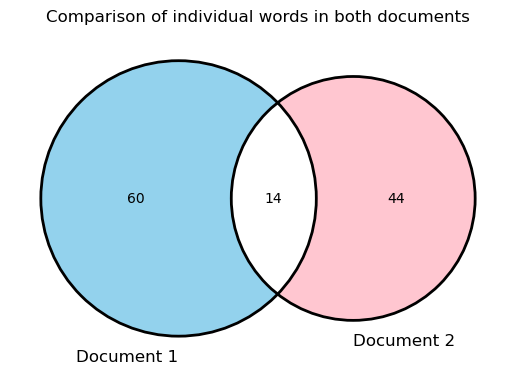

In [39]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2,venn2_circles
# depict venn diagram 
venn2(subsets = (len(set1),len(set2),len(set1.intersection(set2))), 
      set_labels = ('Document 1',  
                    'Document 2'), 
      set_colors=("skyblue", 
                  "pink"),alpha=0.9) 
  
# add outline 
venn2_circles(subsets = (len(set1),len(set2),len(set1.intersection(set2))))  
plt.title("Comparison of individual words in both documents")
plt.show()


In [71]:
import numpy as np
import pandas as pd
from collections import Counter

def generate_trigram_count_matrix(doc):
    trigram_prefixes, vocabulary, trigrams = [], [], []
     
    # Traverse the doc once using a sliding window approach.
    for i in range(len(doc) - 3 + 1):
        # Define the trigram within the sliding window.
        trigram = tuple(doc[i:i+3])
        
        # Extract the bigram prefix.
        bigram_prefix = trigram[0:-1]
        if bigram_prefix not in trigram_prefixes:
            trigram_prefixes.append(bigram_prefix)        
        
        # Extract the last word of the trigram.
        last_word = trigram[-1]
        if last_word not in vocabulary:
            vocabulary.append(last_word)
        
        trigrams.append((bigram_prefix, last_word))
    
    counter = Counter(trigrams)
    
    # Convert the count_matrix to a numpy array to fill in the blanks.
    count_matrix = np.zeros((len(trigram_prefixes), len(vocabulary)))
    
    for key, count in counter.items():
        count_matrix[trigram_prefixes.index(key[0]), vocabulary.index(key[1])] = count
    
    # Convert the numpy array to a pandas DataFrame
    return pd.DataFrame(count_matrix, index=trigram_prefixes, columns=vocabulary)

count_matrix_2 = generate_trigram_count_matrix(filtered_words_doc2)

print(count_matrix_2)

                          second  snowfall  week  kicked  early  friday  \
(d.c., region)               1.0       0.0   0.0     0.0    0.0     0.0   
(region, second)             0.0       1.0   0.0     0.0    0.0     0.0   
(second, snowfall)           0.0       0.0   1.0     0.0    0.0     0.0   
(snowfall, week)             0.0       0.0   0.0     1.0    0.0     0.0   
(week, kicked)               0.0       0.0   0.0     0.0    1.0     0.0   
(kicked, early)              0.0       0.0   0.0     0.0    0.0     1.0   
(early, friday)              0.0       0.0   0.0     0.0    0.0     0.0   
(friday, morning)            0.0       0.0   0.0     0.0    0.0     0.0   
(morning, dumping)           0.0       0.0   0.0     0.0    0.0     0.0   
(dumping, nearly)            0.0       0.0   0.0     0.0    0.0     0.0   
(nearly, 5.5)                0.0       0.0   0.0     0.0    0.0     0.0   
(5.5, inches)                0.0       0.0   0.0     0.0    0.0     0.0   
(inches, snow)           

In [66]:
# create the probability matrix from the count matrix
row_sums_2 = count_matrix_2.sum(axis=1)
# delete each row by its sum
prob_matrix_2 = count_matrix_2.div(row_sums_2, axis=0)

print(prob_matrix_2)

                          second  snowfall  week  kicked  early  friday  \
(d.c., region)               1.0       0.0   0.0     0.0    0.0     0.0   
(region, second)             0.0       1.0   0.0     0.0    0.0     0.0   
(second, snowfall)           0.0       0.0   1.0     0.0    0.0     0.0   
(snowfall, week)             0.0       0.0   0.0     1.0    0.0     0.0   
(week, kicked)               0.0       0.0   0.0     0.0    1.0     0.0   
(kicked, early)              0.0       0.0   0.0     0.0    0.0     1.0   
(early, friday)              0.0       0.0   0.0     0.0    0.0     0.0   
(friday, morning)            0.0       0.0   0.0     0.0    0.0     0.0   
(morning, dumping)           0.0       0.0   0.0     0.0    0.0     0.0   
(dumping, nearly)            0.0       0.0   0.0     0.0    0.0     0.0   
(nearly, 5.5)                0.0       0.0   0.0     0.0    0.0     0.0   
(5.5, inches)                0.0       0.0   0.0     0.0    0.0     0.0   
(inches, snow)           

In [72]:
pd.options.display.max_columns = 500 
pd.options.display.max_rows = 500 
count_matrix_1 = generate_trigram_count_matrix(filtered_words_doc1)

print(count_matrix_1)

                          snowstorm  one  week  blanketed  washington  region  \
(second, significant)           1.0  0.0   0.0        0.0         0.0     0.0   
(significant, snowstorm)        0.0  1.0   0.0        0.0         0.0     0.0   
(snowstorm, one)                0.0  0.0   1.0        0.0         0.0     0.0   
(one, week)                     0.0  0.0   0.0        1.0         0.0     0.0   
(week, blanketed)               0.0  0.0   0.0        0.0         1.0     0.0   
(blanketed, washington)         0.0  0.0   0.0        0.0         0.0     1.0   
(washington, region)            0.0  0.0   0.0        0.0         0.0     0.0   
(region, friday)                0.0  0.0   0.0        0.0         0.0     0.0   
(friday, icing)                 0.0  0.0   0.0        0.0         0.0     0.0   
(icing, roads)                  0.0  0.0   0.0        0.0         0.0     0.0   
(roads, shutting)               0.0  0.0   0.0        0.0         0.0     0.0   
(shutting, schools)         

In [76]:
# create the probability matrix from the count matrix
row_sums_1 = count_matrix_1.sum(axis=1)
# delete each row by its sum
prob_matrix_1 = count_matrix_1.div(row_sums_1, axis=0)

print(prob_matrix_1)

                          snowstorm  one  week  blanketed  washington  region  \
(second, significant)           1.0  0.0   0.0        0.0         0.0     0.0   
(significant, snowstorm)        0.0  1.0   0.0        0.0         0.0     0.0   
(snowstorm, one)                0.0  0.0   1.0        0.0         0.0     0.0   
(one, week)                     0.0  0.0   0.0        1.0         0.0     0.0   
(week, blanketed)               0.0  0.0   0.0        0.0         1.0     0.0   
(blanketed, washington)         0.0  0.0   0.0        0.0         0.0     1.0   
(washington, region)            0.0  0.0   0.0        0.0         0.0     0.0   
(region, friday)                0.0  0.0   0.0        0.0         0.0     0.0   
(friday, icing)                 0.0  0.0   0.0        0.0         0.0     0.0   
(icing, roads)                  0.0  0.0   0.0        0.0         0.0     0.0   
(roads, shutting)               0.0  0.0   0.0        0.0         0.0     0.0   
(shutting, schools)         

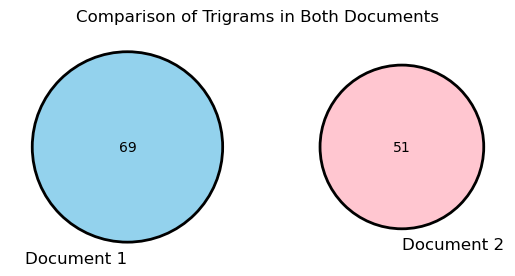

In [77]:
# Extract trigrams from each document
trigrams_doc1 = set(zip(filtered_words_doc1[:-2], filtered_words_doc1[1:-1], filtered_words_doc1[2:]))
trigrams_doc2 = set(zip(filtered_words_doc2[:-2], filtered_words_doc2[1:-1], filtered_words_doc2[2:]))

# Create Venn diagram
venn2(subsets=(len(trigrams_doc1), len(trigrams_doc2), len(trigrams_doc1.intersection(trigrams_doc2))),
      set_labels=('Document 1', 'Document 2'),
      set_colors=("skyblue", "pink"),
      alpha=0.9)

# Add outline
venn2_circles(subsets=(len(trigrams_doc1), len(trigrams_doc2), len(trigrams_doc1.intersection(trigrams_doc2))))

# Add labels
plt.title("Comparison of Trigrams in Both Documents")
plt.show()